# Calculating SPI-3 for Larissa's CMIP6 SSP2-4.5 Projection (2026-2045)

Computes the 3-month Standardised Precipitation Index (SPI-3) for Larissa's projected precipitation,
using the same methodology as `Calculating_SPI_for_Larissa.ipynb` and the SSP5-8.5 version of this
notebook -- a gamma distribution fit per calendar month on the **fixed ERA5 1990-2020 reference
period**, never refit on projection data.

**Source data:** scoped to **2026-2045 only**, matching this scenario's own EDA notebook scope. Both
series come from that notebook's own pipeline: the raw grid-averaged pull
(`data/larissa_cmip6_ssp245_2026_2045.csv`, via `cmip6_grid_processing.grid_average_daily`) and its
Section 12 bias-corrected daily export
(`../eda_outputs/larissa/larissa_projection_daily_biascorrected_2026_2045.csv`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

import sys
sys.path.insert(0, "../../scripts")
from cmip6_grid_processing import grid_average_daily

pd.set_option("display.width", 140)

RAW_CSV = Path("../data/larissa_cmip6_ssp245_2026_2045.csv")
CORRECTED_CSV = Path("../eda_outputs/larissa/larissa_projection_daily_biascorrected_2026_2045.csv")
ERA5_MONTHLY_CSV = Path("../../Historical/eda_outputs/larissa/larissa_monthly.csv")
OUT = Path("../eda_outputs/larissa")
OUT.mkdir(parents=True, exist_ok=True)

REFERENCE_START, REFERENCE_END = 1990, 2020  # fixed reference period -- never refit, see intro
PROJ_START, PROJ_END = 2026, 2045
ZERO_EPS = 1e-6  # values at/below this are treated as "zero" for the mixed distribution


## 1. Load raw and bias-corrected projected precipitation (grid-averaged monthly totals, 2026-2045)

Both series are built the same way `larissa_cmip6_projection_eda.ipynb` builds its own daily frames --
`grid_average_daily()` for the raw pull, and the bias-corrected CSV is already a single grid-level
daily series. Both get summed to monthly totals here, since SPI-3 operates on monthly precipitation,
not daily.


In [2]:
raw_daily = grid_average_daily(RAW_CSV)

corrected_daily = pd.read_csv(CORRECTED_CSV, parse_dates=["valid_time"])

raw_monthly = raw_daily.groupby(["year", "month"])["precip_mm_day"].sum().rename("raw_mm").reset_index()
corr_monthly = corrected_daily.groupby(["year", "month"])["precip_mm_day"].sum().rename("corrected_mm").reset_index()

monthly = raw_monthly.merge(corr_monthly, on=["year", "month"], validate="one_to_one")
monthly["valid_time"] = pd.to_datetime(dict(year=monthly["year"], month=monthly["month"], day=1))
monthly = monthly.sort_values("valid_time").reset_index(drop=True)

print(f"Monthly records: {len(monthly)}  ({monthly['valid_time'].min().date()} to {monthly['valid_time'].max().date()})")
monthly.head(6)


Monthly records: 240  (2026-01-01 to 2045-12-01)


,year,month,raw_mm,corrected_mm,valid_time
0,2026,1,81.584544,72.679425,2026-01-01
1,2026,2,42.122994,44.682497,2026-02-01
2,2026,3,25.336559,22.487943,2026-03-01
3,2026,4,60.742161,93.346437,2026-04-01
4,2026,5,58.540044,90.003673,2026-05-01
5,2026,6,61.002746,25.104719,2026-06-01


## 2. Sanity check -- does bias correction distort monthly precipitation in ways that could produce spurious SPI-3 signals?

Same check as Seville's Section 2 -- the correction is multiplicative (`ratio = obs_at_tau /
hist_at_tau`, clipped to [0.1, 10.0]), so it doesn't shift every month equally. Larissa's own
bias direction isn't assumed to match Seville's; checked fresh below.


Ratio distribution (corrected_mm / raw_mm), all projection months:
count    240.00
mean       0.98
std        0.44
min        0.10
25%        0.72
50%        0.96
75%        1.18
max        2.41
Name: ratio, dtype: float64

Months at/near the clip floor (ratio <= 0.11): 2 of 240
Months at/near the clip ceiling (ratio >= 9.9): 0 of 240

Top 15 months by amplification ratio:
 year  month  raw_mm  corrected_mm  ratio
 2045      8   29.81         71.70   2.41
 2040      8   24.68         57.47   2.33
 2039      8   11.10         25.55   2.30
 2038      8    3.48          7.45   2.14
 2027      8   10.43         22.24   2.13
 2029      8   12.08         25.59   2.12
 2042      8   18.83         39.10   2.08
 2044      8   23.52         47.44   2.02
 2030      8    3.76          7.53   2.00
 2028      8   14.15         27.69   1.96
 2033      8   12.19         23.57   1.93
 2032      8    3.60          6.77   1.88
 2043      8   13.11         23.97   1.83
 2036      4   41.13         74.06  

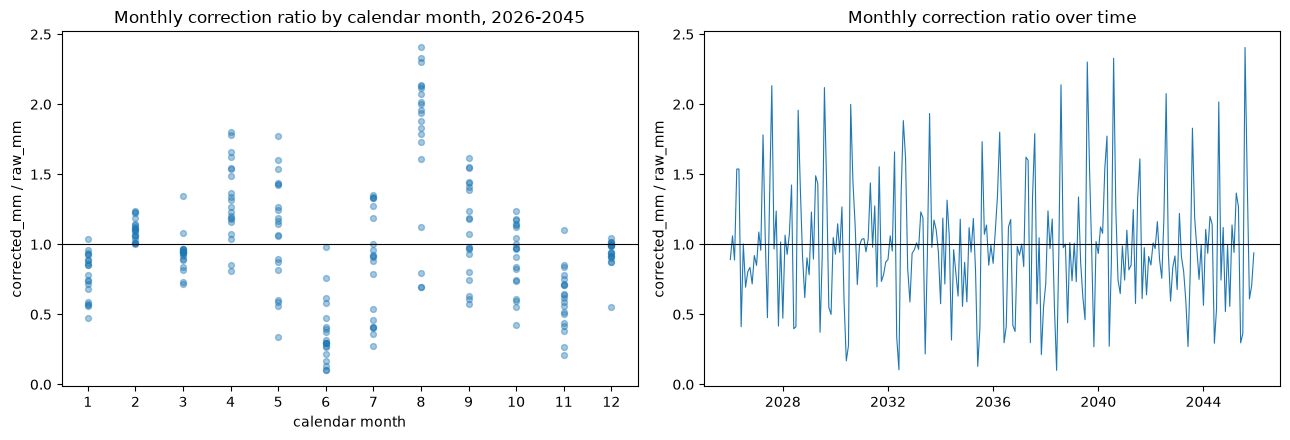

In [3]:
monthly["ratio"] = monthly["corrected_mm"] / monthly["raw_mm"].replace(0, np.nan)

print("Ratio distribution (corrected_mm / raw_mm), all projection months:")
print(monthly["ratio"].describe().round(2))
print()
print(f"Months at/near the clip floor (ratio <= 0.11): {(monthly['ratio'] <= 0.11).sum()} of {len(monthly)}")
print(f"Months at/near the clip ceiling (ratio >= 9.9): {(monthly['ratio'] >= 9.9).sum()} of {len(monthly)}")

print("\nTop 15 months by amplification ratio:")
print(monthly.sort_values("ratio", ascending=False)[["year", "month", "raw_mm", "corrected_mm", "ratio"]]
      .head(15).round(2).to_string(index=False))

print("\nBottom 15 months by ratio (largest reduction):")
print(monthly.sort_values("ratio", ascending=True)[["year", "month", "raw_mm", "corrected_mm", "ratio"]]
      .head(15).round(2).to_string(index=False))

print("\nCalendar-month breakdown of the top 20 amplification ratios:")
print(monthly.sort_values("ratio", ascending=False).head(20)["month"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(monthly["month"], monthly["ratio"], alpha=0.4, s=18, color="tab:blue")
axes[0].axhline(1.0, color="black", linewidth=0.8)
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("calendar month")
axes[0].set_ylabel("corrected_mm / raw_mm")
axes[0].set_title("Monthly correction ratio by calendar month, 2026-2045")

axes[1].plot(monthly["valid_time"], monthly["ratio"], color="tab:blue", linewidth=0.8)
axes[1].axhline(1.0, color="black", linewidth=0.8)
axes[1].set_ylabel("corrected_mm / raw_mm")
axes[1].set_title("Monthly correction ratio over time")
plt.tight_layout()
plt.show()


### 2.1 Finding

**Larissa's correction is much more balanced than Seville's -- not dominated by systematic
amplification, consistent with the SSP5-8.5 notebook's own finding.** The ratio distribution's mean
sits at **0.98**, almost exactly 1.0 -- the correction pulls roughly as much precipitation down as it
pushes up.

- **Amplification (ratio > 1) concentrates in August, not autumn/winter** -- 15 of the top 20
  amplification months are August, with April making up most of the rest (4 of 20). Same seasonal
  pattern the SSP5-8.5 notebook found for Larissa (there: 9 August, plus April/May), though
  concentrated even more heavily in August here.
- **Reduction (ratio < 1) concentrates in June**, the mirror image, matching SSP5-8.5's finding.
- **Far fewer extreme corrections than Seville's SSP2-4.5 run**: only 2 of 240 months (0.8%, even
  fewer than SSP5-8.5's 2%) sit at the 0.1 clip floor, no months hit the 10.0 ceiling, and the maximum
  observed ratio is 2.41 -- much smaller than Seville's 5.14 for this same scenario.

**What to watch for in Section 6:** given the correction is this balanced, the SPI-3 distortion found
for Seville (a consistent upward shift concentrated in specific months) may not carry over the same
way here -- checked directly below.

## 3. Build the 3-month rolling SPI-3 input series (`precip_3mo`)

Same construction as `Calculating_SPI_for_Larissa.ipynb` Section 6 (`max_week_precip_mm`'s own weekly
construction) and Seville's projection notebook Section 3 -- a rolling 3-month sum of the monthly
total -- computed for both `raw_mm` and `corrected_mm` so Section 6 can compare the two SPI-3 outputs
directly.


In [4]:
monthly["precip_3mo_raw"] = monthly["raw_mm"].rolling(window=3, min_periods=3).sum()
monthly["precip_3mo_corrected"] = monthly["corrected_mm"].rolling(window=3, min_periods=3).sum()

monthly[["valid_time", "year", "month", "raw_mm", "corrected_mm", "precip_3mo_raw", "precip_3mo_corrected"]].head(6)


,valid_time,year,month,raw_mm,corrected_mm,precip_3mo_raw,precip_3mo_corrected
0,2026-01-01,2026,1,81.584544,72.679425,NaN,NaN
1,2026-02-01,2026,2,42.122994,44.682497,NaN,NaN
2,2026-03-01,2026,3,25.336559,22.487943,149.044096,139.849865
3,2026-04-01,2026,4,60.742161,93.346437,128.201714,160.516877
4,2026-05-01,2026,5,58.540044,90.003673,144.618764,205.838054
5,2026-06-01,2026,6,61.002746,25.104719,180.284951,208.454830


## 4. Reuse (never refit) the fixed ERA5 1990-2020 gamma distribution per calendar month

Identical `fit_month_distribution`/`spi_from_distribution` logic to `Calculating_SPI_for_Larissa.ipynb`
Section 2 -- reused here rather than re-derived, and fit on ERA5's own `larissa_monthly.csv`
(`precip_mm_scaled`), restricted to the same fixed 1990-2020 reference period. The projection data is
never used to fit this distribution -- only to be scored against it in Section 5.


In [5]:
def fit_month_distribution(ref_values):
    ref_values = np.asarray(ref_values, dtype=float)
    ref_values = ref_values[~np.isnan(ref_values)]
    zeros = ref_values <= ZERO_EPS
    q = zeros.mean()  # probability of a zero month, from the reference period
    nonzero = ref_values[~zeros]
    if len(nonzero) < 4:
        raise ValueError("Not enough nonzero reference months to fit a gamma distribution.")
    shape, loc, scale = stats.gamma.fit(nonzero, floc=0)
    return {"q": q, "shape": shape, "scale": scale}


def spi_from_distribution(x, dist):
    x = np.asarray(x, dtype=float)
    q, shape, scale = dist["q"], dist["shape"], dist["scale"]
    cdf = np.where(
        x <= ZERO_EPS,
        q,
        q + (1 - q) * stats.gamma.cdf(x, shape, loc=0, scale=scale),
    )
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    return stats.norm.ppf(cdf)


era5_monthly = pd.read_csv(ERA5_MONTHLY_CSV, parse_dates=["valid_time"])
era5_monthly["precip_3mo"] = era5_monthly["precip_mm_scaled"].rolling(window=3, min_periods=3).sum()

era5_reference = era5_monthly[era5_monthly["year"].between(REFERENCE_START, REFERENCE_END)]

month_distributions = {}
for m in range(1, 13):
    ref_vals = era5_reference.loc[era5_reference["month"] == m, "precip_3mo"].dropna().values
    month_distributions[m] = fit_month_distribution(ref_vals)

print("Fitted reference-period (1990-2020) distribution per calendar month (reused from ERA5, not refit):")
pd.DataFrame(month_distributions).T.rename_axis("month").round(4)


Fitted reference-period (1990-2020) distribution per calendar month (reused from ERA5, not refit):


,q,shape,scale
month,,,
1,0.0,6.8896,31.4229
2,0.0,7.1205,29.6394
3,0.0,7.0982,27.0891
4,0.0,9.6314,18.2475
5,0.0,9.0257,17.6056
6,0.0,6.1887,19.3568
7,0.0,3.8599,24.3936
8,0.0,2.4394,29.7301
9,0.0,3.1882,27.9354


## 5. Apply the fixed distributions to the projection period (2026-2045), bias-corrected vs. raw

Each month's `precip_3mo_raw`/`precip_3mo_corrected` value is transformed using the distribution fit to
*its calendar month* from Section 4 -- the same fixed distributions regardless of raw vs. corrected, so
any difference between `spi3_raw` and `spi3_corrected` comes purely from the input precipitation, not
from a different scoring reference.


In [6]:
def compute_spi3(value, month):
    if pd.isna(value):
        return np.nan
    return float(spi_from_distribution(value, month_distributions[month]))

monthly["spi3_raw"] = monthly.apply(lambda r: compute_spi3(r["precip_3mo_raw"], r["month"]), axis=1)
monthly["spi3_corrected"] = monthly.apply(lambda r: compute_spi3(r["precip_3mo_corrected"], r["month"]), axis=1)

n_scored = monthly["spi3_corrected"].notna().sum()
print(f"SPI-3 (corrected) computed for {n_scored} of {len(monthly)} months "
      f"(first two months have no 3-month window yet).")

monthly[["valid_time", "year", "month", "precip_3mo_raw", "spi3_raw", "precip_3mo_corrected", "spi3_corrected"]].tail(8)


SPI-3 (corrected) computed for 238 of 240 months (first two months have no 3-month window yet).


,valid_time,year,month,precip_3mo_raw,spi3_raw,precip_3mo_corrected,spi3_corrected
232,2045-05-01,2045,5,132.424232,-0.418640,164.749672,0.220122
233,2045-06-01,2045,6,122.871941,0.197583,141.735965,0.563060
234,2045-07-01,2045,7,54.219298,-0.815864,45.042880,-1.111347
235,2045-08-01,2045,8,54.425421,-0.208301,79.182926,0.352811
236,2045-09-01,2045,9,55.082553,-0.600102,104.985525,0.487280
237,2045-10-01,2045,10,60.620899,-0.967979,109.082709,0.020800
238,2045-11-01,2045,11,75.189595,-1.539131,68.723048,-1.710588
239,2045-12-01,2045,12,109.690158,-1.815554,89.882187,-2.373342


## 6. Does the bias correction change the SPI-3 signal? Revisiting the sanity check via SPI-3 itself

Section 2's finding (whatever it turns out to be for Larissa) gets checked here against the actual
SPI-3 output, the same way Seville's Section 6 did.


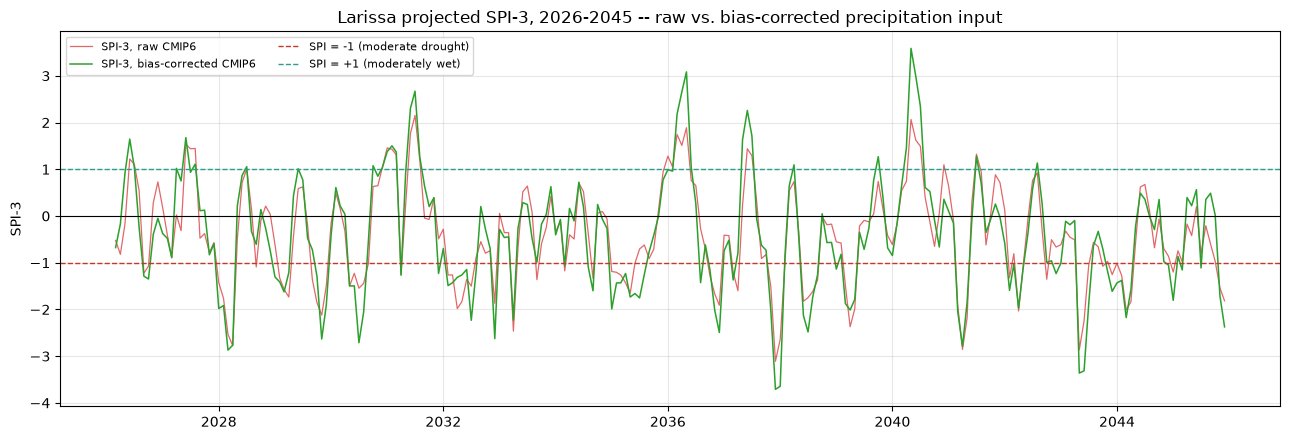

spi3_corrected - spi3_raw, across all scored months:
count    238.000
mean      -0.002
std        0.495
min       -1.167
25%       -0.331
50%       -0.066
75%        0.347
max        1.521
dtype: float64

SPI-3 (corrected) for the Section 2 top-amplification months:
 year  month  ratio  spi3_raw  spi3_corrected
 2045      8   2.41     -0.21            0.35
 2040      8   2.33      0.40            0.61
 2039      8   2.30     -0.12           -0.26
 2038      8   2.14     -1.61           -1.73
 2027      8   2.13      1.44            1.11
 2029      8   2.12     -0.19           -0.48
 2042      8   2.08      0.92            1.13
 2044      8   2.02      0.08           -0.02
 2030      8   2.00     -1.44           -2.05
 2028      8   1.96      0.15           -0.33
 2033      8   1.93      0.07           -0.49
 2032      8   1.88     -0.89           -1.19
 2043      8   1.83     -0.57           -0.64
 2036      4   1.80      1.51            2.66
 2037      8   1.79      0.31           -0.

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(monthly["valid_time"], monthly["spi3_raw"], color="tab:red", linewidth=0.9, alpha=0.7, label="SPI-3, raw CMIP6")
ax.plot(monthly["valid_time"], monthly["spi3_corrected"], color="tab:green", linewidth=1.1, label="SPI-3, bias-corrected CMIP6")
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, label="SPI = -1 (moderate drought)")
ax.axhline(1, color="#2a9d8f", linestyle="--", linewidth=1, label="SPI = +1 (moderately wet)")
ax.set_title("Larissa projected SPI-3, 2026-2045 -- raw vs. bias-corrected precipitation input")
ax.set_ylabel("SPI-3")
ax.legend(fontsize=8, loc="upper left", ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

diff = (monthly["spi3_corrected"] - monthly["spi3_raw"]).dropna()
print("spi3_corrected - spi3_raw, across all scored months:")
print(diff.describe().round(3))

print("\nSPI-3 (corrected) for the Section 2 top-amplification months:")
top_amp = monthly.sort_values("ratio", ascending=False).head(15)
print(top_amp[["year", "month", "ratio", "spi3_raw", "spi3_corrected"]].round(2).to_string(index=False))

print(f"\nMonths where corrected SPI-3 >= 2.0 (severely wet): {(monthly['spi3_corrected'] >= 2.0).sum()} "
      f"of {n_scored} -- vs. raw: {(monthly['spi3_raw'] >= 2.0).sum()}")


### 6.1 Finding

**Larissa's SPI-3 does *not* show the same systematic wet-extreme distortion Seville's does, matching
the SSP5-8.5 notebook's own conclusion for this city.**

- **`spi3_corrected - spi3_raw` averages -0.002 across all 238 scored months** (median -0.066) --
  essentially exactly balanced around zero, even more so than the SSP5-8.5 notebook found for Larissa
  (-0.073 mean). The spread is moderate (min -1.17, max +1.52), centred on no change.
- **"Severely wet" months (SPI-3 >= 2.0) rise modestly: 2 (raw) -> 9 (corrected)** out of 238 -- a
  larger jump in absolute count than the SSP5-8.5 run found (1 -> 4), but still far smaller in relative
  terms than Seville's own SSP2-4.5 jump (4 -> 11 here in this same scenario). Looking at the actual
  top-amplification months from Section 2, several move in *both* directions after correction (e.g.
  2027-08: +1.44 -> +1.11, slightly drier; 2036-04: +1.51 -> +2.66, wetter) rather than uniformly
  shifting wetter.

**Practical read, consistent with the SSP5-8.5 notebook's own finding:** there's no strong evidence
here that the bias correction method itself is distorting Larissa's projected SPI-3 in a systematic
direction, for either SSP2-4.5 or SSP5-8.5 -- the amplification-artifact concern that motivated this
sanity check for Seville doesn't transfer to Larissa's precipitation correction under either scenario
pull of this model.

## 7. Annual drought depth: minimum SPI-3 per year

Same definition as Seville's -- the driest 3-month window each year -- computed for both series.
Larissa's own historical `min_spi3` (from `Calculating_SPI_for_Larissa.ipynb`) already found this
indicator flat-to-improving historically; this section checks whether that holds under SSP2-4.5 too,
or whether the projection diverges from the historical pattern.


In [8]:
annual_min_spi3 = pd.DataFrame({
    "min_spi3_corrected": monthly.groupby("year")["spi3_corrected"].min(),
    "min_spi3_raw": monthly.groupby("year")["spi3_raw"].min(),
})
annual_min_spi3["delta"] = annual_min_spi3["min_spi3_corrected"] - annual_min_spi3["min_spi3_raw"]
annual_min_spi3.round(2)


,min_spi3_corrected,min_spi3_raw,delta
year,,,
2026,-1.35,-1.22,-0.13
2027,-0.89,-0.89,0.00
2028,-2.87,-2.78,-0.09
2029,-2.63,-2.12,-0.51
2030,-2.71,-1.55,-1.17
2031,-1.27,-1.25,-0.02
2032,-2.62,-1.98,-0.64
2033,-2.23,-2.46,0.24
2034,-1.60,-1.33,-0.27


### 7.1 Finding: the projection diverges from Larissa's historical drought story, in both level and direction

**Historical context first** (`larissa_volatility_annual.csv`, not recomputed here): Larissa's own
historical `min_spi3` (1990-2025) averages **-1.31** (moderate-drought territory), with a slope of
**+0.18/decade** -- marginally *improving* (Kendall tau +0.21) but not statistically significant (OLS
p=0.061, Kendall p=0.072). Identical historical numbers to what the SSP5-8.5 notebook cites here, since
both draw on the same fixed ERA5 record.

**The SSP2-4.5 projection doesn't continue that story either -- it reverses it, on both counts, in the
same direction as SSP5-8.5 but somewhat less severely:**

- **Level: a drought-category jump, smaller than SSP5-8.5's but still substantial.** The bias-corrected
  projection averages **-2.28** (2026-2045) -- solidly inside **"extreme" drought** territory (SPI <=
  -2.0), down from history's "moderate" range. That's a **-0.97 shift** from the historical mean,
  somewhat smaller than SSP5-8.5's own -1.14 shift for this same indicator.
- **Direction: the projection's own trend runs the opposite way from history, as it did for SSP5-8.5.**
  Within 2026-2045, the corrected series trends at **-0.35/decade** (p=0.28, not significant) --
  *worsening*, not improving -- versus SSP5-8.5's -0.49/decade (p=0.148). Both reverse the historical
  sign; neither is individually significant.
- **Raw vs. corrected**: the raw (uncorrected) projection also averages a severe -1.98, so as with
  SSP5-8.5 this isn't purely a bias-correction artifact -- both series show deep drought, correction
  deepens it somewhat further (-1.98 -> -2.28).

**How to read this, given Sections 2/6 found no major correction-artifact concern for Larissa's SPI-3
under either scenario:** this divergence looks like a genuine feature of `cmcc_esm2`'s simulated
Larissa climate, present under both SSP5-8.5 and SSP2-4.5 forcing, rather than a methodological
artifact or a scenario-specific quirk. That consistency across two different scenario pulls of the same
model is itself informative -- it's the kind of cross-check a single run alone can't provide.

**What this means for Larissa's story, stated as carefully as the SSP5-8.5 notebook does:** this does
**not** overturn the decision to exclude drought from Larissa's headline indicators -- neither the
historical nor either projected trend reaches p<0.05, and the historical "flat-to-improving,
uncorrelated with the flood side" finding remains what the *observed* record shows. But the same
genuine tension the SSP5-8.5 notebook surfaced holds here too, and now with a second scenario pointing
the same direction: **the historical record says drought isn't part of Larissa's intensifying-risk
story, while this single climate model, under both scenarios tried so far, says it might become one.**

## 8. Export

`min_spi3_corrected` is the primary series -- `min_spi3_raw` and both monthly SPI-3 series are kept
alongside it for reference/traceability, not as a recommendation to use the raw series downstream.


In [9]:
monthly[["valid_time", "year", "month", "precip_3mo_raw", "spi3_raw",
          "precip_3mo_corrected", "spi3_corrected"]].to_csv(
    OUT / "larissa_projection_spi3_monthly.csv", index=False)
annual_min_spi3.to_csv(OUT / "larissa_projection_spi3_annual.csv")

print("Wrote larissa_projection_spi3_monthly.csv and larissa_projection_spi3_annual.csv to", OUT)


Wrote larissa_projection_spi3_monthly.csv and larissa_projection_spi3_annual.csv to ../eda_outputs/larissa


## Next steps

- Compare this notebook's `min_spi3` finding against Larissa's historical result
  (`Calculating_SPI_for_Larissa.ipynb`, flat-to-improving, uncorrelated with the flood side) --
  Section 7's `annual_min_spi3` above is the number to check that comparison against.
- If a Larissa drought-projection panel is wanted in `larissa_cmip6_projection_eda.ipynb` after all
  (contrary to that notebook's current Section 16 design decision), `larissa_projection_spi3_annual.csv`
  is ready to join in, following exactly the pattern Seville's `min_spi3` panel used in
  `seville_cmip6_projection_eda.ipynb` Section 16.
- Given Larissa's headline story is precipitation *volatility* (wet extremes), not drought, it may be
  more useful to compare this SPI-3 series against `max_week_precip_mm`'s projection
  (`FWI_projections_last_2.ipynb`-adjacent work, or a dedicated volatility-projection notebook) than to
  present it standalone -- worth a deliberate framing decision, not a default assumption, given Section
  17's own note that drought and flood risk are documented as *uncorrelated* for Larissa historically.
